<a href="https://colab.research.google.com/github/dokunoale/chagas/blob/feature%2FLSTM/notebooks/1.Simple_LSTM_%26_GRU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Caricamento dataset e librerie

In [1]:
!git clone -b feature/LSTM https://github.com/dokunoale/chagas.git
!pip install -r chagas/requirements.txt

# Download the dataset
import gdown

url = "https://drive.google.com/file/d/1vK_gMI36xjdtiJjMBV7dKHurIExQs4hC/view?usp=drive_link"
gdown.download(url, "dataset.zip", quiet=False, fuzzy=True)
!unzip -q /content/dataset.zip -d chagas/data/

Cloning into 'chagas'...
remote: Enumerating objects: 445, done.
remote: Counting objects: 100% (175/175), done.
remote: Compressing objects: 100% (138/138), done.
remote: Total 445 (delta 80), reused 92 (delta 36), pack-reused 270 (from 1)
Receiving objects: 100% (445/445), 5.14 MiB | 31.34 MiB/s, done.
Resolving deltas: 100% (204/204), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 121.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.0/160.0 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 24.7 MB/s eta 0:00:00
  Attempting uninstall: joblib
    Found existing installation: joblib 1.5.1
    Uninstalling joblib-1.5.1:
      Successfully uninstalled joblib-1.5.1
  Attempting uninstall: h5py
    Found existing installation: h5py 3.14.0
    Uninstalling h5py-3.14.0:
      Successfully uninstalled h5py-3.14.0
  Attempting uninstall: scikit-learn

Downloading...
From (original): https://drive.google.com/uc?id=1vK_gMI36xjdtiJjMBV7dKHurIExQs4hC
From (redirected): https://drive.google.com/uc?id=1vK_gMI36xjdtiJjMBV7dKHurIExQs4hC&confirm=t&uuid=76a214e2-4373-4f2e-b3ab-e2a5f0fa9bc2
To: /content/dataset.zip
100%|██████████| 623M/623M [00:04<00:00, 129MB/s]


In [3]:
import sys
sys.path.append("/content/chagas/src")

import os

import tensorflow as tf
from tensorflow.keras.layers import Layer
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.metrics import AUC

import numpy as np
from sklearn.model_selection import train_test_split
from scipy.signal import iirnotch, butter, filtfilt

from preprocessing.tf_dataset_loader import load_dataset, concatenate_and_shuffle
from preprocessing.denoiser import *
from models.utils import *
from models.build_LSTM import build_ecg_lstm_model
from models.build_GRU import build_ecg_gru_model

In [4]:
# Carichiamo il dataset
data_path = "/content/chagas/data/big_splitted_dataset/"

X_train, y_train = concatenate_and_shuffle(
    load_dataset(data_path + "train/positives"),
    load_dataset(data_path + "train/negatives"))

X_val, y_val = concatenate_and_shuffle(
    load_dataset(data_path + "val/positives"),
    load_dataset(data_path + "val/negatives"))

X_test, y_test = concatenate_and_shuffle(
    load_dataset(data_path + "test/positives"),
    load_dataset(data_path + "test/negatives"))

In [5]:
print(f"TRAIN SHAPE: {X_train.shape} - VALIDATION SHAPE: {X_val.shape} - TEST SHAPE: {X_test.shape}")

TRAIN SHAPE: (7855, 2800, 12) - VALIDATION SHAPE: (1122, 2800, 12) - TEST SHAPE: (2245, 2800, 12)


In [6]:
y_train = y_train.astype(int)
y_val = y_val.astype(int)
y_test = y_test.astype(int)

In [7]:
X_train = filtfilt_noise_reduction(X_train, fs=400, iir_freq=60.0, butterworth_cutoff=5., lowpass_cutoff=60.)
X_val = filtfilt_noise_reduction(X_val, fs=400, iir_freq=60.0, butterworth_cutoff=5., lowpass_cutoff=60.)
X_test = filtfilt_noise_reduction(X_test, fs=400, iir_freq=60.0, butterworth_cutoff=5., lowpass_cutoff=60.)

# LSTM

In [8]:
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import AUC

In [9]:
model = build_ecg_lstm_model(dropout_rate=0.5)

#compiliamo il modello
model.compile(optimizer='adam',
              loss=BinaryCrossentropy(),
              metrics=['accuracy', AUC(name='auc')])

#addestriamo il modello
callback = make_callback("LSTM")

history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=15,
                    batch_size=32,
                    callbacks=callback)

Epoch 1/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - accuracy: 0.5006 - auc: 0.5091 - loss: 0.6961
Epoch 1: val_auc improved from -inf to 0.49693, saving model to LSTM_best_model.keras
246/246 ━━━━━━━━━━━━━━━━━━━━ 91s 344ms/step - accuracy: 0.5006 - auc: 0.5091 - loss: 0.6961 - val_accuracy: 0.5018 - val_auc: 0.4969 - val_loss: 0.6972 - learning_rate: 0.0010
Epoch 2/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - accuracy: 0.5011 - auc: 0.5069 - loss: 0.6957
Epoch 2: val_auc improved from 0.49693 to 0.50333, saving model to LSTM_best_model.keras
246/246 ━━━━━━━━━━━━━━━━━━━━ 87s 353ms/step - accuracy: 0.5011 - auc: 0.5069 - loss: 0.6957 - val_accuracy: 0.5036 - val_auc: 0.5033 - val_loss: 0.6936 - learning_rate: 0.0010
Epoch 3/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.5056 - auc: 0.5060 - loss: 0.6948
Epoch 3: val_auc improved from 0.50333 to 0.50713, saving model to LSTM_best_model.keras
246/246 ━━━━━━━━━━━━━━━━━━━━ 86s 351ms/step - accuracy: 0.5056 - auc: 0.5059 -

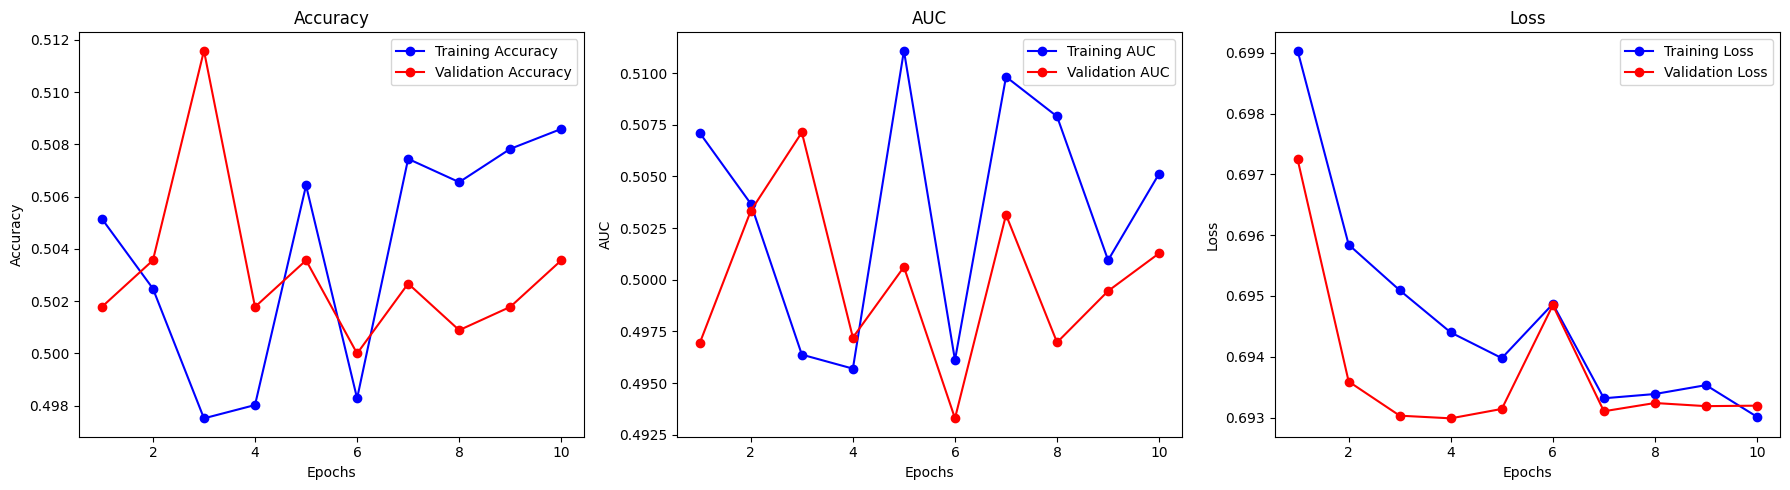

In [10]:
plot_training_metrics(history)

Possiamo notare osservando la scala di valori che il modello non ha imparato praticamente niente nel corso delle prime 10 epoche

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
model_path = "/content/drive/MyDrive/chagas_models/simple_LSTM_model.keras"
model.save(model_path)

# GRU

In [15]:
model = build_ecg_gru_model(dropout_rate=0.5)

#compiliamo il modello
model.compile(optimizer='adam',
              loss=BinaryCrossentropy(),
              metrics=['accuracy', AUC(name='auc')])

#addestriamo il modello
callback = make_callback("GRU")

history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=15,
                    batch_size=32,
                    callbacks=callback)

Epoch 1/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.5104 - auc: 0.5170 - loss: 0.6933
Epoch 1: val_auc improved from -inf to 0.58859, saving model to GRU_best_model.keras
246/246 ━━━━━━━━━━━━━━━━━━━━ 93s 364ms/step - accuracy: 0.5104 - auc: 0.5171 - loss: 0.6933 - val_accuracy: 0.5392 - val_auc: 0.5886 - val_loss: 0.6851 - learning_rate: 0.0010
Epoch 2/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.5326 - auc: 0.5529 - loss: 0.6898
Epoch 2: val_auc did not improve from 0.58859
246/246 ━━━━━━━━━━━━━━━━━━━━ 88s 360ms/step - accuracy: 0.5326 - auc: 0.5529 - loss: 0.6898 - val_accuracy: 0.5312 - val_auc: 0.5688 - val_loss: 0.6900 - learning_rate: 0.0010
Epoch 3/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.5129 - auc: 0.5176 - loss: 0.6965
Epoch 3: val_auc improved from 0.58859 to 0.60207, saving model to GRU_best_model.keras
246/246 ━━━━━━━━━━━━━━━━━━━━ 89s 362ms/step - accuracy: 0.5129 - auc: 0.5176 - loss: 0.6965 - val_accuracy: 0.5615 - val_au

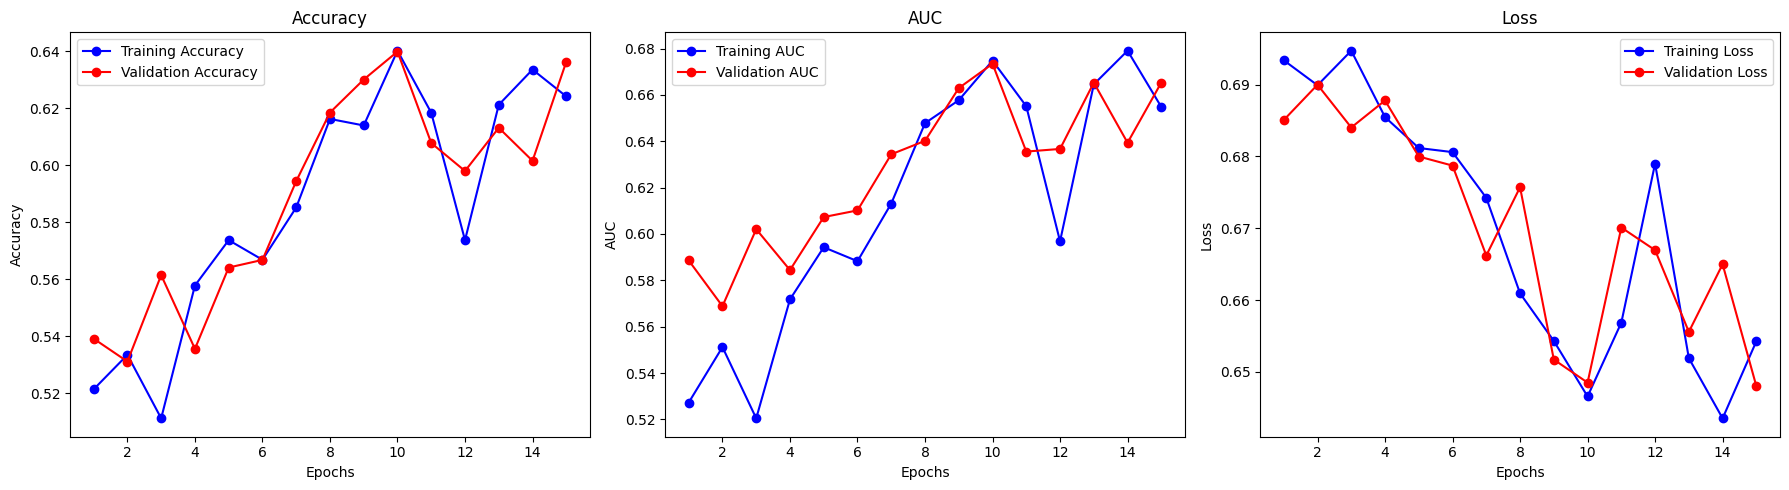

In [16]:
plot_training_metrics(history)

Osserviamo che la stessa architettura in cui mettiamo delle GRU al posto delle LSTM dà risultati decisamente migliori, nonostante molto lontani da ciò che si vorrebbe ottenere

In [17]:
model_path = "/content/drive/MyDrive/chagas_models/simple_GRU_model.keras"
model.save(model_path)